# Generate test images and fake aquisition from the mnt data

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random


import tkinter as tk
from tkinter import filedialog

C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\pysal\explore\segregation\network\network.py:16: UserWarning: You need pandana and urbanaccess to work with segregation's network module
You can install them with  `pip install urbanaccess pandana` or `conda install -c udst pandana urbanaccess`
  "You need pandana and urbanaccess to work with segregation's network module\n"


Intro :
We define here the parameters, and the training image in which we will cut the data.

In [2]:
#Load the data
file_path = './datas/TI/MNT_2016_TI_Alt2.tif'
size_img = np.array([400,400])
number_of_aquisition_lines = 3
define_border = True
error = 2
num_img = 3

if os.path.isfile(file_path):
    print('Le fichier est présent. import')
    data_DEM = gr.from_file(file_path)
    (xmin, xsize, x, ymax, y, ysize) = data_DEM.geot

else:
    print('error')

Le fichier est présent. import


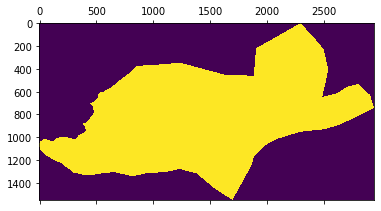

In [4]:
print('Sizes Infos :')

print(data_DEM.geot)
print(data_DEM.shape)
x_v = np.array(range(data_DEM.shape[1]))*2 + data_DEM.geot[3]
y_v = np.array(range(data_DEM.shape[0]))*2 + data_DEM.geot[0]
Y_dem, X_dem = np.meshgrid(x_v,y_v)


Sizes Infos :
(583288.0, 2.0, 0.0, 131222.0, 0.0, -2.0)
(1555, 2943)


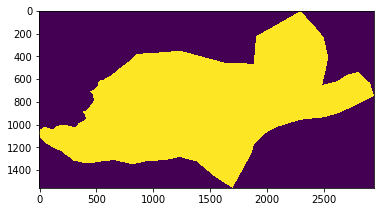

In [4]:
mask_where_nodata = data_DEM.raster != np.min(data_DEM.raster)

plt.imshow(mask_where_nodata)

In [5]:
data_DEM.shape[0]

1555

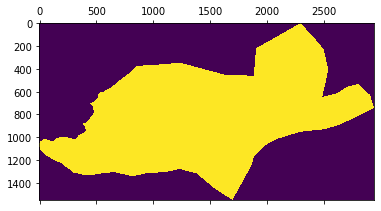

In [6]:
data_DEM.plot()

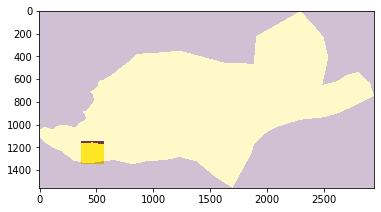

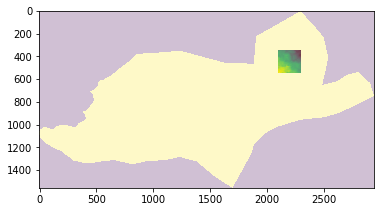

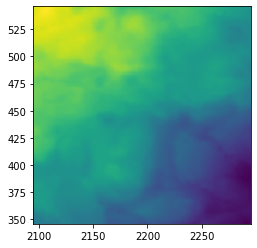

In [8]:
res = False
while res == False:
    plt.close()
    size_img_c = (np.round(size_img / data_DEM.geot[1]))
    rdm_X = int(round(random()*(data_DEM.shape[1] - size_img_c[0])))
    rdm_Y = int(round(random()*(data_DEM.shape[0] - size_img_c[1])))

    box = [rdm_X, int(rdm_X+size_img_c[0]),rdm_Y,int(rdm_Y+size_img_c[1])]
    mask_cut = mask_where_nodata[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))]
    raster_cut = data_DEM.raster[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))]
    New_TI = np.array(data_DEM.raster)
    New_TI[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))] = data_DEM.nodata_value
    res = np.all(mask_cut)
    #a = np.ones(raster_cut.shape)*100000000
    plt.imshow(raster_cut, extent = box)
    plt.imshow(data_DEM.raster,alpha=0.25)
    
    plt.show()
    time.sleep(3)
    
plt.figure()
plt.imshow(raster_cut, extent = box)



In [9]:
hard_data = pd.DataFrame()
line = np.zeros([2,2])

for i in range(number_of_aquisition_lines):

    top = [round(random()),round(random())]
    if top[0] == 1:  #Vertical start
        line[:,0] = np.array([round(random()*(box[1]-box[0]) + box[0]),box[2]])#return a x value, defined a y
    else:
        line[:,0] = np.array([box[0],round(random()*(box[3]-box[2]) + box[2])]) #return a x value, defined a y

    if top[1] == 1:
        line[:,1] = np.array([round(random()*(box[1]-box[0]) + box[0]),box[3]]) #return a x value, defined a y
    else:
        line[:,1] = np.array([box[1],round(random()*(box[3]-box[2]) + box[2])]) #return a x value, defined a y

    dx = np.max(np.diff(line))

    x_pos = np.round(np.linspace(line[0,0],line[0,1],num =dx))
    y_pos = np.round(np.linspace(line[1,0],line[1,1],num =dx))

    d = {'cell_x': x_pos, 'cell_y': y_pos}
    pos_index = pd.DataFrame(d)
    pos_index["cell_x"] = pos_index["cell_x"].astype(int)
    pos_index["cell_y"] = pos_index["cell_y"].astype(int)
    pos_index['alt'] = data_DEM.raster[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['X'] = X_dem[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['Y'] = Y_dem[pos_index["cell_y"],pos_index["cell_x"]]

    hard_data = hard_data.append(pos_index, ignore_index = True)


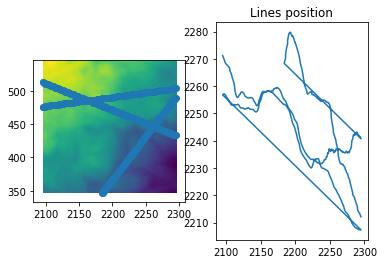

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)
plt.title('Lines position')

ax1.imshow(raster_cut, extent = box)
ax1.scatter(hard_data["cell_x"],hard_data["cell_y"] )

ax2.plot(hard_data["cell_x"],hard_data["alt"])

In [11]:
if define_border:
    x_cells = np.array(range(box[0],box[1]))
    y_cells = np.array(range(box[2],box[3]))
    
    x_pos = np.append(np.tile(x_cells,2),np.tile(x_cells[0],y_cells.size))#,)
    y_pos = np.append(np.tile(y_cells[0],x_cells.size),np.tile(y_cells[-1],x_cells.size))#)
    
    x_pos = np.append(x_pos,np.tile(x_cells[-1],y_cells.size))
    y_pos = np.append(y_pos,np.tile(y_cells,2))
    #x_pos = x_pos.append()
    
    d = {'cell_x': x_pos, 'cell_y': y_pos}
    pos_index = pd.DataFrame(d)
    pos_index["cell_x"] = pos_index["cell_x"].astype(int)
    pos_index["cell_y"] = pos_index["cell_y"].astype(int)
    
    pos_index['alt'] = data_DEM.raster[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['X'] = X_dem[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['Y'] = Y_dem[pos_index["cell_y"],pos_index["cell_x"]]
    
    hard_data = hard_data.append(pos_index, ignore_index = True)


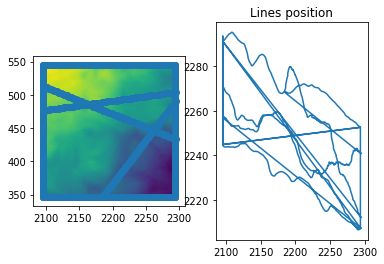

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2)
plt.title('Lines position')

ax1.imshow(raster_cut, extent = box)
ax1.scatter(hard_data["cell_x"],hard_data["cell_y"] )

ax2.plot(hard_data["cell_x"],hard_data["alt"])

In [13]:
synthe_name = 'realisation' 
save_path = './generated_data'
if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)



In [14]:
with open(save_path + '/' + synthe_name + str(1) + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([raster_cut.data, box, hard_data,New_TI], f, pickle.HIGHEST_PROTOCOL)

In [15]:
raster_cut

masked_array(
  data=[[2291.051513671875, 2291.271240234375, 2291.55419921875, ...,
         2253.064208984375, 2252.817138671875, 2252.55517578125],
        [2291.084716796875, 2291.41162109375, 2291.70166015625, ...,
         2252.822998046875, 2252.580322265625, 2252.377685546875],
        [2291.018310546875, 2291.38037109375, 2291.74267578125, ...,
         2252.624755859375, 2252.389892578125, 2252.203369140625],
        ...,
        [2244.599853515625, 2244.271728515625, 2244.152587890625, ...,
         2207.544677734375, 2208.060302734375, 2208.504150390625],
        [2244.5849609375, 2244.071044921875, 2243.8271484375, ...,
         2207.126953125, 2207.566650390625, 2207.9921875],
        [2244.8505859375, 2244.19873046875, 2243.87890625, ...,
         2206.74951171875, 2207.1279296875, 2207.588134765625]],
  mask=[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
 

In [ ]:
num = int(input("Enter number :") )

In [ ]:
class ProgressBar:
    '''
    Progress bar
    '''
    def __init__ (self, valmax, maxbar, title):
        if valmax == 0:  valmax = 1
        if maxbar > 200: maxbar = 200
        self.valmax = valmax
        self.maxbar = maxbar
        self.title  = title
    
    def update(self, val):
        import sys
        # format
        if val > self.valmax: val = self.valmax
        
        # process
        perc  = round((float(val) / float(self.valmax)) * 100)
        scale = 100.0 / float(self.maxbar)
        bar   = int(perc / scale)
  
        # render 
        out = '\r %20s [%s%s] %3d %%' % (self.title, '=' * bar, ' ' * (self.maxbar - bar), perc)
        sys.stdout.write(out)

In [ ]:
Bar = ProgressBar(100, 60, 'MonTitre')
for i in range(100):
    Bar.update(i)
    time.sleep(0.5)